# Fig. 2E: 最新 season 结果（Overall / H1N1 / H3N2）

本 notebook 生成三个 season 39--44 的排名矩阵：Overall、H1N1 和 H3N2。每个 season 内根据 MAE、MSE、Pearson、Spearman、R² 对三个模型排序。Overall 是将 H1N1 与 H3N2 的测试预测样本合并后重新计算的指标，不是亚型指标的简单平均。

所有数值可在下一单元格中直接手动编辑。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ===== 手动填写最新 season 数值 =====
# 每行的五个数字依次为：[MAE, MSE, Pearson, Spearman, R2]。
# 每个模型下的六行顺序对应 SEASONS；修改模型或 season 时请同步修改全部配置。
SEASONS = ['39', '40', '41', '42', '43', '44']
METRICS = ['MAE', 'MSE', 'Pearson', 'Spearman', 'R2']
MODELS = ['FluAgPredictor', 'Adaboost', 'Nextflu']
DISPLAY_NAMES = {'FluAgPredictor': 'fluAgPredictor', 'Adaboost': 'AdaBoost', 'Nextflu': 'Nextflu'}
MODEL_COLORS = {'FluAgPredictor': '#aec2d3', 'Adaboost': '#bcc8b8', 'Nextflu': '#dcd6a5'}
HIGHER_BETTER = {'Pearson', 'Spearman', 'R2'}

SEASON_VALUES = {
    'Overall': {
        'FluAgPredictor': [[0.8892, 1.2196, 0.7846, 0.7665, 0.5830], [0.8587, 1.1611, 0.8337, 0.8146, 0.6155], [0.8772, 1.2845, 0.4937, 0.4978, 0.2174], [0.9427, 1.7690, 0.3782, 0.4336, 0.0932], [0.7331, 0.8921, 0.7340, 0.6538, 0.5243], [1.1127, 2.5628, 0.6384, 0.6916, 0.3186]],
        'Adaboost':         [[0.9769, 1.7023, 0.7346, 0.7159, 0.4181], [0.7953, 1.2174, 0.8054, 0.7978, 0.5968], [0.8126, 1.1944, 0.5885, 0.5992, 0.2723], [0.9067, 1.6255, 0.4758, 0.5060, 0.1668], [0.7573, 1.1486, 0.6433, 0.6418, 0.3875], [1.0685, 2.2596, 0.6877, 0.6735, 0.3992]],
        'Nextflu':          [[1.1033, 1.8391, 0.7377, 0.7310, 0.3713], [0.8363, 1.1309, 0.7937, 0.7860, 0.6255], [0.9043, 1.3893, 0.4264, 0.3694, 0.1536], [1.0919, 2.2680, 0.2761, 0.3218, -0.1625], [0.8737, 1.2630, 0.6993, 0.4791, 0.3265], [1.2456, 3.3725, 0.5630, 0.4683, 0.1033]],
    },
    'H1N1': {
        'FluAgPredictor': [[0.8632, 1.1153, 0.8933, 0.7572, 0.7915], [0.8529, 1.1201, 0.9001, 0.7141, 0.7343], [0.8164, 0.9585, 0.4177, 0.4538, -0.2041], [0.5832, 0.5972, 0.4214, 0.4140, 0.1647], [0.5929, 0.5997, 0.3569, 0.3005, 0.0263], [0.6600, 0.7330, 0.5241, 0.4749, 0.2672]],
        'Adaboost':         [[0.8017, 1.1184, 0.8988, 0.8236, 0.7909], [0.7702, 1.1792, 0.8772, 0.7132, 0.7202], [0.6661, 0.7996, 0.2916, 0.3034, -0.0046], [0.5542, 0.7229, 0.3644, 0.3581, -0.0112], [0.5645, 0.6842, 0.3030, 0.2731, -0.1108], [0.6462, 0.8876, 0.3889, 0.4028, 0.1126]],
        'Nextflu':          [[1.0216, 1.4987, 0.8660, 0.7126, 0.7198], [0.7845, 1.0182, 0.8736, 0.6582, 0.7584], [0.7704, 0.8853, 0.3362, 0.3527, -0.1122], [0.5722, 0.5912, 0.4297, 0.4004, 0.1731], [0.5719, 0.5438, 0.4204, 0.3595, 0.1171], [0.6930, 0.8216, 0.4604, 0.3647, 0.1787]],
    },
    'H3N2': {
        'FluAgPredictor': [[0.8999, 1.2629, 0.6503, 0.6480, 0.3407], [0.8636, 1.1954, 0.6535, 0.6646, 0.3089], [0.9239, 1.5353, 0.2887, 0.3325, -0.2025], [1.0685, 2.1791, 0.2322, 0.2760, -0.0694], [0.8176, 1.0683, 0.7138, 0.6843, 0.4920], [1.4863, 4.0728, 0.4098, 0.4025, -0.1265]],
        'Adaboost':         [[1.0496, 1.9445, 0.5377, 0.5475, -0.0151], [0.8163, 1.2494, 0.5935, 0.6220, 0.2776], [0.9253, 1.4981, 0.2847, 0.2861, -0.1734], [1.0300, 1.9413, 0.3582, 0.3880, 0.0473], [0.8736, 1.4286, 0.5811, 0.6337, 0.3207], [1.4169, 3.3918, 0.5193, 0.5270, 0.0619]],
        'Nextflu':          [[1.1372, 1.9803, 0.5747, 0.5547, -0.0338], [0.8797, 1.2251, 0.6086, 0.6173, 0.2917], [1.0073, 1.7770, 0.2224, 0.2316, -0.3919], [1.2738, 2.8548, 0.1570, 0.1802, -0.4010], [1.0557, 1.6966, 0.7016, 0.5311, 0.1932], [1.7016, 5.4775, 0.4511, 0.3675, -0.5150]],
    },
}

OUTPUT_PATHS = {'Overall': None, 'H1N1': None, 'H3N2': None}


value                            rank                 \
model           Adaboost FluAgPredictor Nextflu Adaboost FluAgPredictor   
season metric                                                             
39     MAE        0.9769         0.8892  1.1033      2.0            1.0   
       MSE        1.7023         1.2196  1.8391      2.0            1.0   
       Pearson    0.7346         0.7846  0.7377      3.0            1.0   
       R2         0.4181         0.5830  0.3713      2.0            1.0   
       Spearman   0.7159         0.7665  0.7310      3.0            1.0   
40     MAE        0.7953         0.8587  0.8363      1.0            3.0   
       MSE        1.2174         1.1611  1.1309      3.0            2.0   
       Pearson    0.8054         0.8337  0.7937      2.0            1.0   
       R2         0.5968         0.6155  0.6255      3.0            2.0   
       Spearman   0.7978         0.8146  0.7860      2.0            1.0   
41     MAE        0.8126         0.8772  0.9043      1.0            2.0   
       MSE        1.1944         1.2845  1.3893      1.0            2.0   
       Pearson    0.5885         0.4937  0.4264      1.0            2.0   
       R2         0.2723         0.2174  0.1536      1.0            2.0   
       Spearman   0.5992         0.4978  0.3694      1.0            2.0   
42     MAE        0.9067         0.9427  1.0919      1.0            2.0   
       MSE        1.6255         1.7690  2.2680      1.0            2.0   
       Pearson    0.4758         0.3782  0.2761      1.0            2.0   
       R2         0.1668         0.0932 -0.1625      1.0            2.0   
       Spearman   0.5060         0.4336  0.3218      1.0            2.0   
43     MAE        0.7573         0.7331  0.8737      2.0            1.0   
       MSE        1.1486         0.8921  1.2630      2.0            1.0   
       Pearson    0.6433         0.7340  0.6993      3.0            1.0   
       R2         0.3875         0.5243  0.3265      2.0            1.0   
       Spearman   0.6418         0.6538  0.4791      2.0            1.0   
44     MAE        1.0685         1.1127  1.2456      1.0            2.0   
       MSE        2.2596         2.5628  3.3725      1.0            2.0   
       Pearson    0.6877         0.6384  0.5630      1.0            2.0   
       R2         0.3992         0.3186  0.1033      1.0            2.0   
       Spearman   0.6735         0.6916  0.4683      2.0            1.0   

                         
model           Nextflu  
season metric            
39     MAE          3.0  
       MSE          3.0  
       Pearson      2.0  
       R2           3.0  
       Spearman     2.0  
40     MAE          2.0  
       MSE          1.0  
       Pearson      3.0  
       R2           1.0  
       Spearman     3.0  
41     MAE          3.0  
       MSE          3.0  
       Pearson      3.0  
       R2           3.0  
       Spearman     3.0  
42     MAE          3.0  
       MSE          3.0  
       Pearson      3.0  
       R2           3.0  
       Spearman     3.0  
43     MAE          3.0  
       MSE          3.0  
       Pearson      2.0  
       R2           3.0  
       Spearman     3.0  
44     MAE          3.0  
       MSE          3.0  
       Pearson      3.0  
       R2           3.0  
       Spearman     3.0

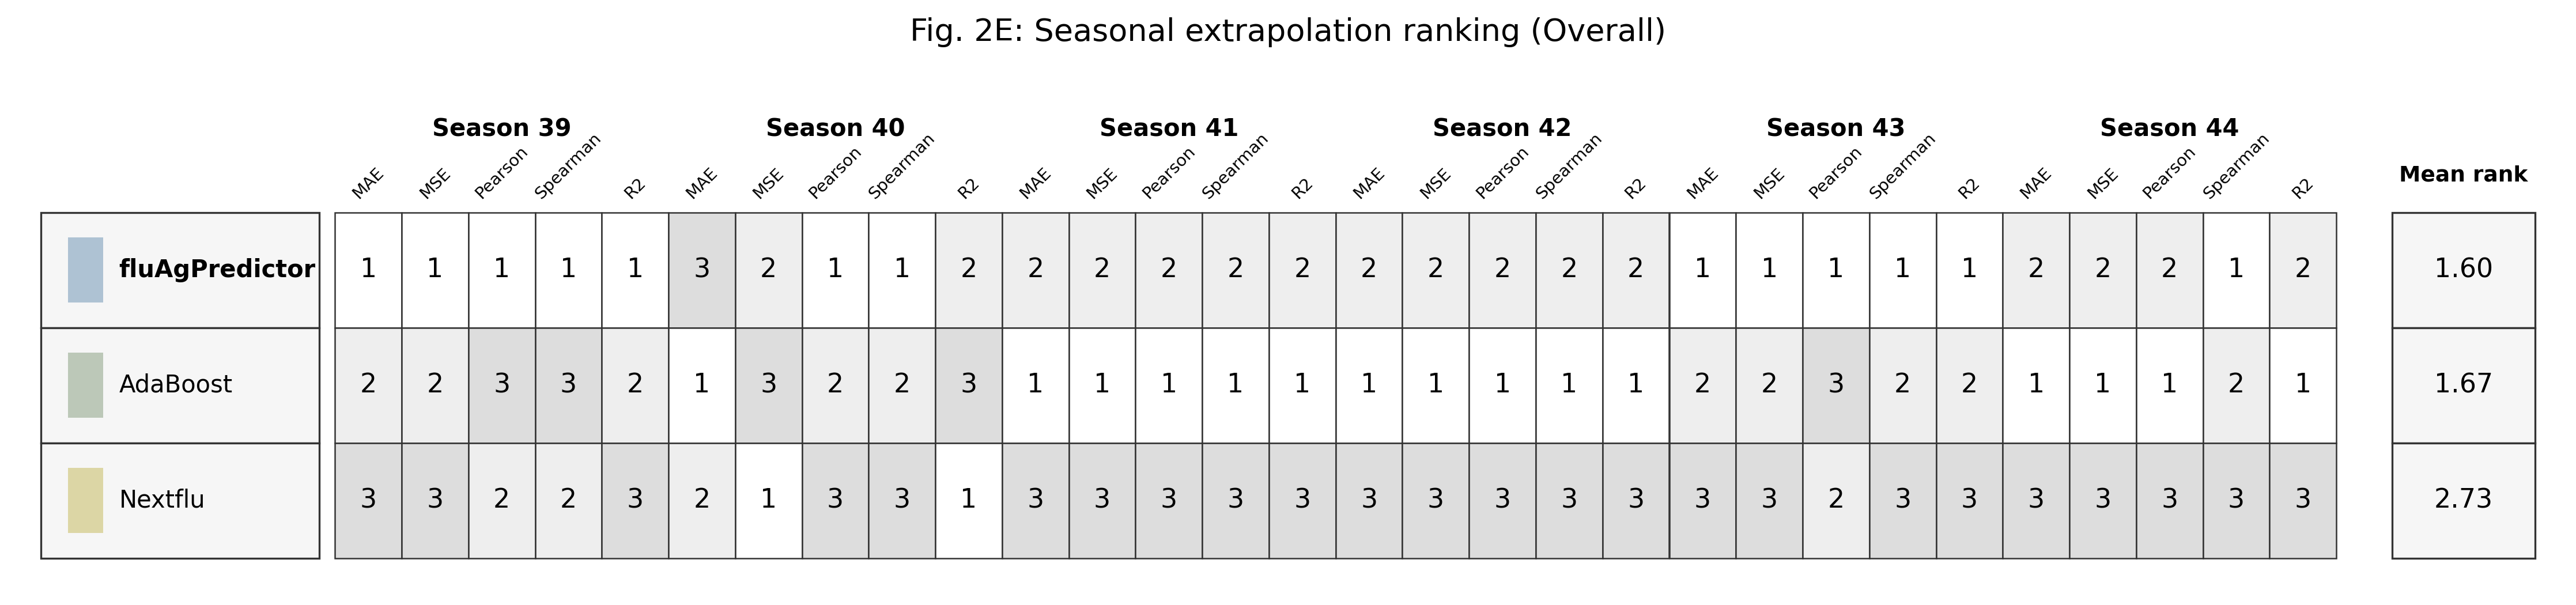

value                            rank                 \
model           Adaboost FluAgPredictor Nextflu Adaboost FluAgPredictor   
season metric                                                             
39     MAE        0.8017         0.8632  1.0216      1.0            2.0   
       MSE        1.1184         1.1153  1.4987      2.0            1.0   
       Pearson    0.8988         0.8933  0.8660      1.0            2.0   
       R2         0.7909         0.7915  0.7198      2.0            1.0   
       Spearman   0.8236         0.7572  0.7126      1.0            2.0   
40     MAE        0.7702         0.8529  0.7845      1.0            3.0   
       MSE        1.1792         1.1201  1.0182      3.0            2.0   
       Pearson    0.8772         0.9001  0.8736      2.0            1.0   
       R2         0.7202         0.7343  0.7584      3.0            2.0   
       Spearman   0.7132         0.7141  0.6582      2.0            1.0   
41     MAE        0.6661         0.8164  0.7704      1.0            3.0   
       MSE        0.7996         0.9585  0.8853      1.0            3.0   
       Pearson    0.2916         0.4177  0.3362      3.0            1.0   
       R2        -0.0046        -0.2041 -0.1122      1.0            3.0   
       Spearman   0.3034         0.4538  0.3527      3.0            1.0   
42     MAE        0.5542         0.5832  0.5722      1.0            3.0   
       MSE        0.7229         0.5972  0.5912      3.0            2.0   
       Pearson    0.3644         0.4214  0.4297      3.0            2.0   
       R2        -0.0112         0.1647  0.1731      3.0            2.0   
       Spearman   0.3581         0.4140  0.4004      3.0            1.0   
43     MAE        0.5645         0.5929  0.5719      1.0            3.0   
       MSE        0.6842         0.5997  0.5438      3.0            2.0   
       Pearson    0.3030         0.3569  0.4204      3.0            2.0   
       R2        -0.1108         0.0263  0.1171      3.0            2.0   
       Spearman   0.2731         0.3005  0.3595      3.0            2.0   
44     MAE        0.6462         0.6600  0.6930      1.0            2.0   
       MSE        0.8876         0.7330  0.8216      3.0            1.0   
       Pearson    0.3889         0.5241  0.4604      3.0            1.0   
       R2         0.1126         0.2672  0.1787      3.0            1.0   
       Spearman   0.4028         0.4749  0.3647      2.0            1.0   

                         
model           Nextflu  
season metric            
39     MAE          3.0  
       MSE          3.0  
       Pearson      3.0  
       R2           3.0  
       Spearman     3.0  
40     MAE          2.0  
       MSE          1.0  
       Pearson      3.0  
       R2           1.0  
       Spearman     3.0  
41     MAE          2.0  
       MSE          2.0  
       Pearson      2.0  
       R2           2.0  
       Spearman     2.0  
42     MAE          2.0  
       MSE          1.0  
       Pearson      1.0  
       R2           1.0  
       Spearman     2.0  
43     MAE          2.0  
       MSE          1.0  
       Pearson      1.0  
       R2           1.0  
       Spearman     1.0  
44     MAE          3.0  
       MSE          2.0  
       Pearson      2.0  
       R2           2.0  
       Spearman     3.0

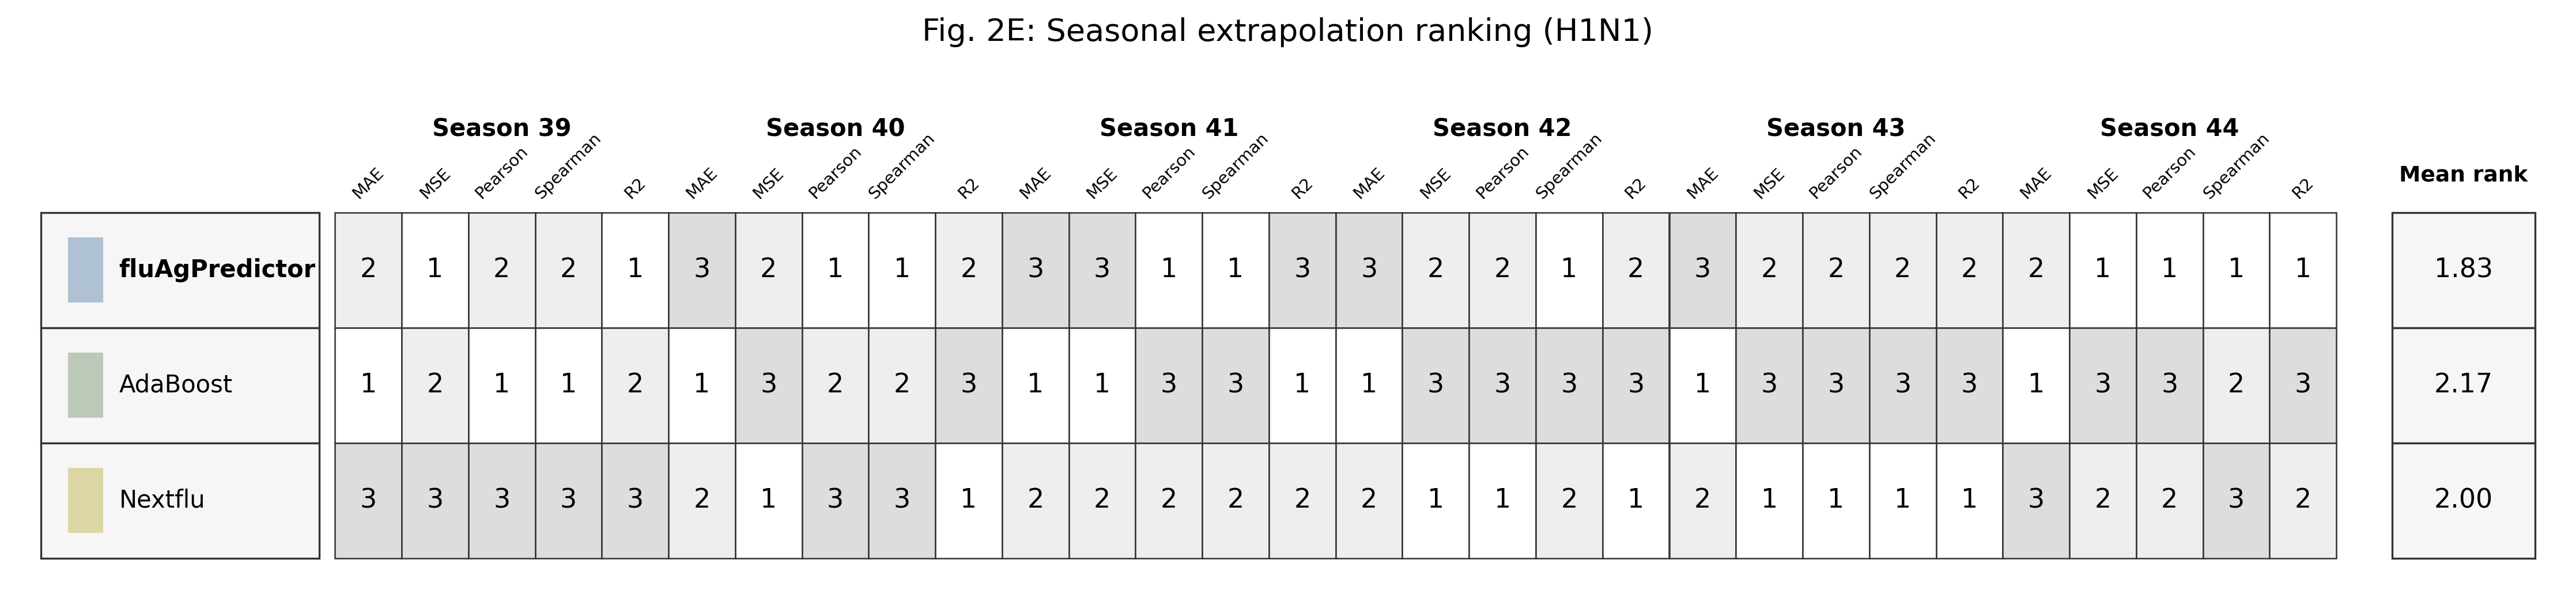

value                            rank                 \
model           Adaboost FluAgPredictor Nextflu Adaboost FluAgPredictor   
season metric                                                             
39     MAE        1.0496         0.8999  1.1372      2.0            1.0   
       MSE        1.9445         1.2629  1.9803      2.0            1.0   
       Pearson    0.5377         0.6503  0.5747      3.0            1.0   
       R2        -0.0151         0.3407 -0.0338      2.0            1.0   
       Spearman   0.5475         0.6480  0.5547      3.0            1.0   
40     MAE        0.8163         0.8636  0.8797      1.0            2.0   
       MSE        1.2494         1.1954  1.2251      3.0            1.0   
       Pearson    0.5935         0.6535  0.6086      3.0            1.0   
       R2         0.2776         0.3089  0.2917      3.0            1.0   
       Spearman   0.6220         0.6646  0.6173      2.0            1.0   
41     MAE        0.9253         0.9239  1.0073      2.0            1.0   
       MSE        1.4981         1.5353  1.7770      1.0            2.0   
       Pearson    0.2847         0.2887  0.2224      2.0            1.0   
       R2        -0.1734        -0.2025 -0.3919      1.0            2.0   
       Spearman   0.2861         0.3325  0.2316      2.0            1.0   
42     MAE        1.0300         1.0685  1.2738      1.0            2.0   
       MSE        1.9413         2.1791  2.8548      1.0            2.0   
       Pearson    0.3582         0.2322  0.1570      1.0            2.0   
       R2         0.0473        -0.0694 -0.4010      1.0            2.0   
       Spearman   0.3880         0.2760  0.1802      1.0            2.0   
43     MAE        0.8736         0.8176  1.0557      2.0            1.0   
       MSE        1.4286         1.0683  1.6966      2.0            1.0   
       Pearson    0.5811         0.7138  0.7016      3.0            1.0   
       R2         0.3207         0.4920  0.1932      2.0            1.0   
       Spearman   0.6337         0.6843  0.5311      2.0            1.0   
44     MAE        1.4169         1.4863  1.7016      1.0            2.0   
       MSE        3.3918         4.0728  5.4775      1.0            2.0   
       Pearson    0.5193         0.4098  0.4511      1.0            3.0   
       R2         0.0619        -0.1265 -0.5150      1.0            2.0   
       Spearman   0.5270         0.4025  0.3675      1.0            2.0   

                         
model           Nextflu  
season metric            
39     MAE          3.0  
       MSE          3.0  
       Pearson      2.0  
       R2           3.0  
       Spearman     2.0  
40     MAE          3.0  
       MSE          2.0  
       Pearson      2.0  
       R2           2.0  
       Spearman     3.0  
41     MAE          3.0  
       MSE          3.0  
       Pearson      3.0  
       R2           3.0  
       Spearman     3.0  
42     MAE          3.0  
       MSE          3.0  
       Pearson      3.0  
       R2           3.0  
       Spearman     3.0  
43     MAE          3.0  
       MSE          3.0  
       Pearson      2.0  
       R2           3.0  
       Spearman     3.0  
44     MAE          3.0  
       MSE          3.0  
       Pearson      2.0  
       R2           3.0  
       Spearman     3.0

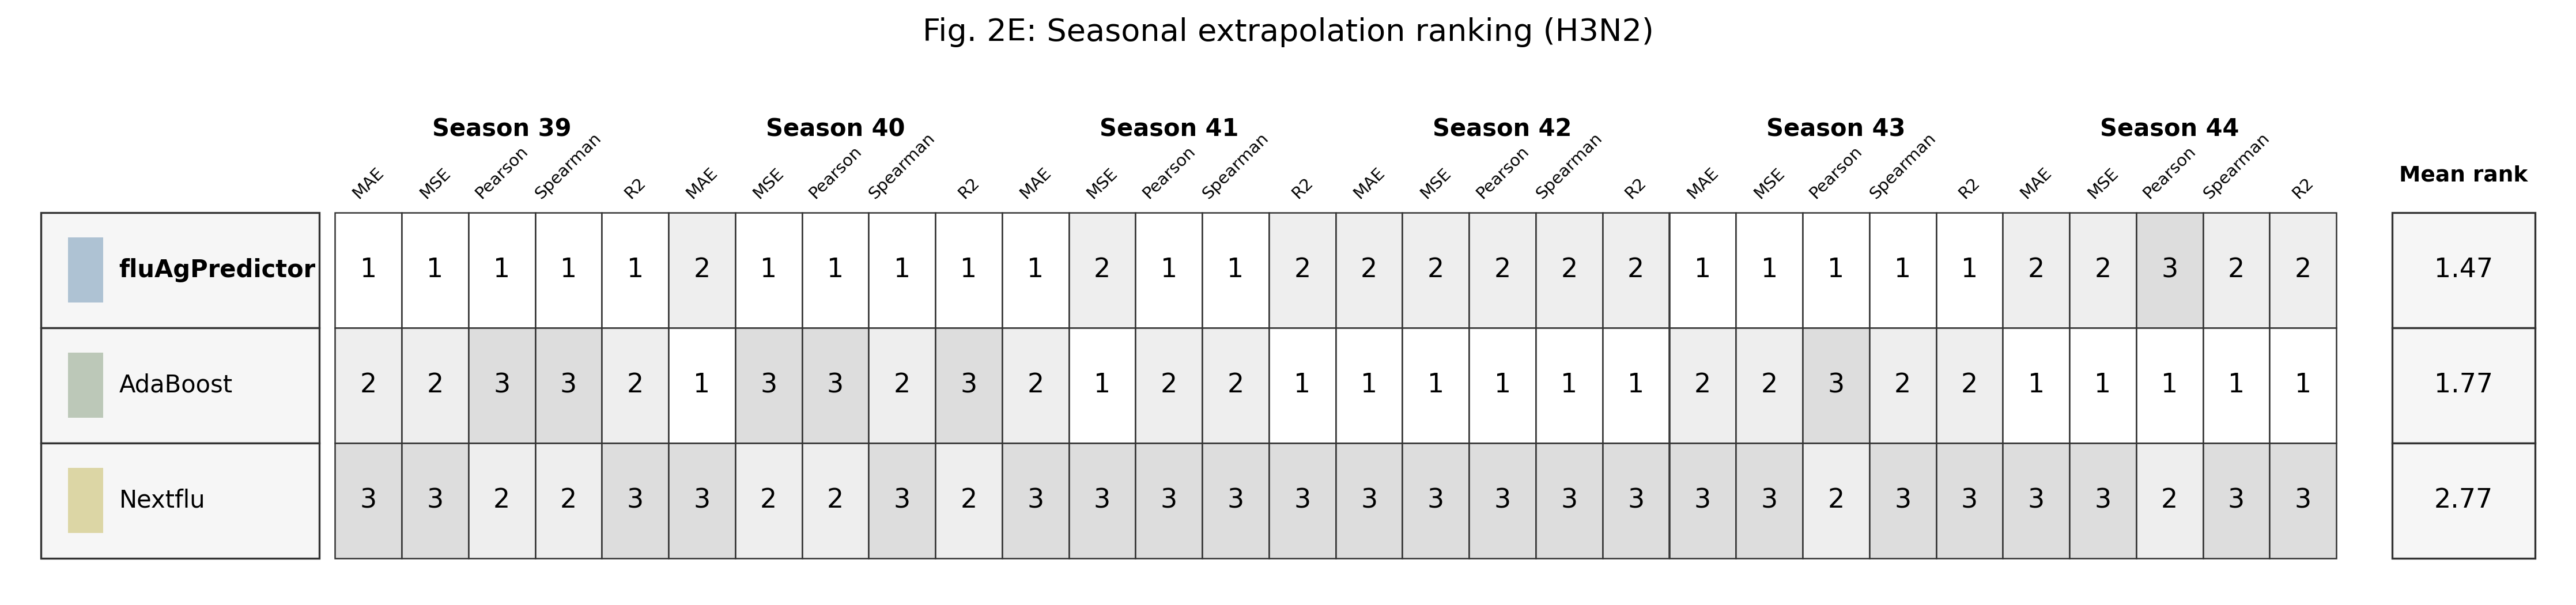

In [2]:
def build_rank_table(values_by_model):
    rows = []
    for season_index, season in enumerate(SEASONS):
        for metric_index, metric in enumerate(METRICS):
            values = {model: values_by_model[model][season_index][metric_index] for model in MODELS}
            ranks = pd.Series(values).rank(method='min', ascending=metric not in HIGHER_BETTER).astype(int)
            for model in MODELS:
                rows.append({'season': season, 'metric': metric, 'model': model, 'value': values[model], 'rank': int(ranks[model])})
    return pd.DataFrame(rows)

def plot_rank_matrix(panel_name, rank_df, output_path=None):
    cell_w, cell_h, left, bottom = 0.42, 0.78, 2.2, 0.75
    fig, ax = plt.subplots(figsize=(15, 3.6), dpi=300)
    rank_colors = {1: '#ffffff', 2: '#eeeeee', 3: '#dddddd'}
    for row_index, model in enumerate(MODELS):
        y = bottom + (len(MODELS) - 1 - row_index) * cell_h
        ax.add_patch(Rectangle((left - 1.85, y), 1.75, cell_h, facecolor='#f6f6f6', edgecolor='#333333', linewidth=0.8))
        ax.add_patch(Rectangle((left - 1.68, y + 0.17), 0.22, 0.44, facecolor=MODEL_COLORS[model], edgecolor='none'))
        ax.text(left - 1.36, y + cell_h / 2, DISPLAY_NAMES[model], ha='left', va='center', fontsize=10, fontweight='bold' if model == 'FluAgPredictor' else None)
        for season_index, season in enumerate(SEASONS):
            for metric_index, metric in enumerate(METRICS):
                x = left + (season_index * len(METRICS) + metric_index) * cell_w
                rank = int(rank_df.query('season == @season and metric == @metric and model == @model')['rank'].iloc[0])
                ax.add_patch(Rectangle((x, y), cell_w, cell_h, facecolor=rank_colors[rank], edgecolor='#333333', linewidth=0.6))
                ax.text(x + cell_w / 2, y + cell_h / 2, str(rank), ha='center', va='center', fontsize=11)
    for season_index, season in enumerate(SEASONS):
        start_x = left + season_index * len(METRICS) * cell_w
        ax.text(start_x + len(METRICS) * cell_w / 2, bottom + len(MODELS) * cell_h + 0.48, f'Season {season}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        for metric_index, metric in enumerate(METRICS):
            ax.text(start_x + (metric_index + 0.5) * cell_w, bottom + len(MODELS) * cell_h + 0.07, metric, ha='center', va='bottom', fontsize=7, rotation=45)
    summary_x = left + len(SEASONS) * len(METRICS) * cell_w + 0.35
    ax.text(summary_x + 0.45, bottom + len(MODELS) * cell_h + 0.18, 'Mean rank', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for row_index, model in enumerate(MODELS):
        y = bottom + (len(MODELS) - 1 - row_index) * cell_h
        mean_rank = rank_df.loc[rank_df['model'] == model, 'rank'].mean()
        ax.add_patch(Rectangle((summary_x, y), 0.9, cell_h, facecolor='#f6f6f6', edgecolor='#333333', linewidth=0.8))
        ax.text(summary_x + 0.45, y + cell_h / 2, f'{mean_rank:.2f}', ha='center', va='center', fontsize=11)
    ax.set_title(f'Fig. 2E: Seasonal extrapolation ranking ({panel_name})', fontsize=13, pad=16)
    ax.set_xlim(left - 2.0, summary_x + 1.05); ax.set_ylim(bottom - 0.2, bottom + len(MODELS) * cell_h + 0.9)
    ax.axis('off')
    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, bbox_inches='tight')
        print(f'Saved {panel_name} figure to: {output_path}')
    plt.show()

rank_tables = {}
for panel_name in ('Overall', 'H1N1', 'H3N2'):
    rank_tables[panel_name] = build_rank_table(SEASON_VALUES[panel_name])
    display(rank_tables[panel_name].pivot(index=['season', 'metric'], columns='model', values=['value', 'rank']).round(4))
    plot_rank_matrix(panel_name, rank_tables[panel_name], OUTPUT_PATHS[panel_name])
